In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from pathlib import Path

# Define paths
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/Agentic_AI/Unsupervised_Anonamlous.zip'
output_directory = Path('/content') / 'bearing_data_unzipped'

# Create the output directory if it doesn't exist
output_directory.mkdir(parents=True, exist_ok=True)

print(f"Attempting to unzip '{zip_file_path}' to '{output_directory}'")
!unzip -o "{zip_file_path}" -d "{output_directory}"

print(f"'{zip_file_path}' unzipped to '{output_directory}' successfully.")

Streaming output truncated to the last 5000 lines.
  inflating: /content/bearing_data_unzipped/Unsupervised_Anonamlous/venv/lib/python3.12/site-packages/pandas/tests/io/parser/__pycache__/test_compression.cpython-312.pyc  
  inflating: /content/bearing_data_unzipped/__MACOSX/Unsupervised_Anonamlous/venv/lib/python3.12/site-packages/pandas/tests/io/parser/__pycache__/._test_compression.cpython-312.pyc  
  inflating: /content/bearing_data_unzipped/Unsupervised_Anonamlous/venv/lib/python3.12/site-packages/pandas/tests/io/parser/__pycache__/test_comment.cpython-312.pyc  
  inflating: /content/bearing_data_unzipped/__MACOSX/Unsupervised_Anonamlous/venv/lib/python3.12/site-packages/pandas/tests/io/parser/__pycache__/._test_comment.cpython-312.pyc  
  inflating: /content/bearing_data_unzipped/Unsupervised_Anonamlous/venv/lib/python3.12/site-packages/pandas/tests/io/parser/__pycache__/test_na_values.cpython-312.pyc  
  inflating: /content/bearing_data_unzipped/__MACOSX/Unsupervised_Anonamlous/

Loaded attributes: (1200, 3)
Numeric attribute columns: ['d1p', 'd1v']
Found 2999 audio files
Audio chunk length: 65536 samples (~4.10s)
Loaded attributes: (1200, 3)
Numeric attribute columns: ['d1p', 'd1v']
Found 600 audio files
Audio chunk length: 65536 samples (~4.10s)


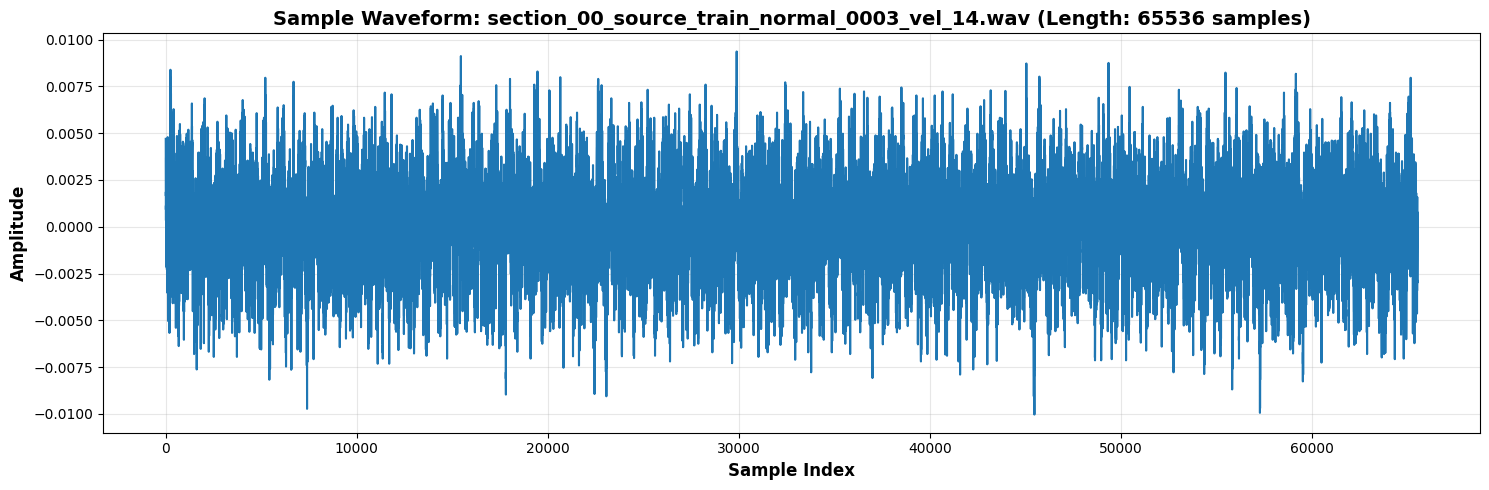

Displaying waveform for: section_00_source_train_normal_0003_vel_14.wav
Waveform shape: (65536,)


In [6]:
import os
from pathlib import Path # Explicitly import Path
import numpy as np
import pandas as pd
import librosa
import torch
from torch.utils.data import Dataset, DataLoader, Subset # Combine Subset with Dataset, DataLoader
import matplotlib.pyplot as plt

# Define BearingDataset class
class BearingDataset(Dataset):
    """Bearing audio waveforms + optional numeric attributes from CSV."""

    def __init__(self, data_dir, attributes_file, sr=16000, duration=None, transform=None):
        self.data_dir = Path(data_dir)
        self.sr = sr
        self.fixed_length = 65536  # 2^16; divisible by 2^k for k pooling stages
        self.duration = duration
        self.transform = transform

        self.attributes = pd.read_csv(attributes_file)
        numeric_columns = []
        for col in self.attributes.columns[1:]:
            self.attributes[col] = pd.to_numeric(self.attributes[col], errors="coerce")
            if self.attributes[col].dtype in ["float64", "int64"]:
                numeric_columns.append(col)
        if numeric_columns:
            self.attributes = self.attributes[["file_name"] + numeric_columns]
        self.attributes = self.attributes.fillna(0)

        print(f"Loaded attributes: {self.attributes.shape}")
        print(f"Numeric attribute columns: {numeric_columns}")

        self.audio_files = sorted(
            f for f in os.listdir(data_dir) if f.endswith((".wav", ".mp3", ".flac"))
        )
        if len(self.audio_files) == 0:
            raise ValueError(f"No audio files found in {data_dir}")
        print(
            f"Found {len(self.audio_files)} audio files"
        )
        print(
            f"Audio chunk length: {self.fixed_length} samples (~{self.fixed_length / self.sr:.2f}s)"
        )

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, idx):
        audio_path = self.data_dir / self.audio_files[idx]
        waveform, _ = librosa.load(str(audio_path), sr=self.sr, duration=self.duration)

        if len(waveform) < self.fixed_length:
            waveform = np.pad(waveform, (0, self.fixed_length - len(waveform)), mode="constant")
        else:
            waveform = waveform[: self.fixed_length]

        waveform = torch.from_numpy(waveform).float().unsqueeze(0)
        if self.transform:
            waveform = self.transform(waveform)

        filename = self.audio_files[idx]
        attr_row = self.attributes[
            self.attributes.iloc[:, 0].astype(str).str.contains(
                filename.split(".")[0], case=False, na=False
            )
        ]
        if len(attr_row) > 0:
            try:
                attr_values = pd.to_numeric(attr_row.iloc[0, 1:].values, errors="coerce")
                attr_values = np.nan_to_num(attr_values, nan=0.0)
                attributes = torch.from_numpy(attr_values.astype(np.float32)).float()
            except Exception as e:
                print(f"Warning: Could not convert attributes for {filename}: {e}")
                attributes = torch.zeros(self.attributes.shape[1] - 1)
        else:
            attributes = torch.zeros(self.attributes.shape[1] - 1)

        return {"waveform": waveform, "attributes": attributes, "filename": filename}

# Re-initialize necessary variables if the kernel state was reset
# These variables are defined in cell af1c6cb3 and earlier cells
# Assuming BEARING_DIR, SR, BearingDataset, Path, attributes_file are available from previous executions

# Define paths (from cell 9bc10590)
PROJECT_ROOT = Path.cwd()
BEARING_DIR = Path('/content') / 'bearing_data_unzipped' / 'Unsupervised_Anonamlous' / 'bearing'
RESULTS_DIR = PROJECT_ROOT / "results"

# Config values (from cell af1c6cb3)
SMOKE_TEST = False  # Set to False as per previous execution state
MAX_TRAIN_SAMPLES = 16
SR = 16000

# Data directory paths
train_dir = BEARING_DIR / "train"
test_dir = BEARING_DIR / "test"

# Attributes file (from cell af1c6cb3)
attributes_files = sorted(BEARING_DIR.glob("attributes_*.csv"))
if not attributes_files:
    raise ValueError(f"No attributes CSV files found in {BEARING_DIR}")
attributes_file = str(attributes_files[0])

# Instantiate base datasets
train_base_ds = BearingDataset(str(train_dir), attributes_file, sr=SR)
val_base_ds = BearingDataset(str(test_dir), attributes_file, sr=SR)

# Determine train_ds based on SMOKE_TEST flag (from cell af1c6cb3)
if SMOKE_TEST:
    train_ds = Subset(train_base_ds, range(min(MAX_TRAIN_SAMPLES, len(train_base_ds))))
else:
    train_ds = train_base_ds
# Get a single sample from the training dataset
sample_idx = 3  # You can change this index to view different samples
sample = train_ds[sample_idx]

waveform = sample['waveform'].squeeze().cpu().numpy()
filename = sample['filename']

plt.figure(figsize=(15, 5))
plt.plot(waveform)
plt.title(f'Sample Waveform: {filename} (Length: {len(waveform)} samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index', fontsize=12, fontweight='bold')
plt.ylabel('Amplitude', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Displaying waveform for: {filename}")
print(f"Waveform shape: {waveform.shape}")


In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
)

# Project root (directory containing this notebook)
PROJECT_ROOT = Path.cwd()
# Corrected BEARING_DIR to point to the unzipped data's bearing folder
BEARING_DIR = Path('/content') / 'bearing_data_unzipped' / 'Unsupervised_Anonamlous' / 'bearing'
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

In [9]:
class ConvBlock(nn.Module):
    """Two Conv1d + BN + ReLU blocks (same pattern as the original repo)."""

    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=True),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=True),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet1D(nn.Module):
    """
    Compact 1D U-Net: three encoder levels (32, 64, 128) + bottleneck 256.
    Input length should be divisible by 2**3 = 8 (65536 is fine).
    """

    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        c1, c2, c3, cb = 32, 64, 128, 256

        self.enc1 = ConvBlock(in_channels, c1)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock(c1, c2)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock(c2, c3)
        self.pool3 = nn.MaxPool1d(2)

        self.bottleneck = ConvBlock(c3, cb)

        self.upconv3 = nn.ConvTranspose1d(cb, c3, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(c3 + c3, c3)
        self.upconv2 = nn.ConvTranspose1d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(c2 + c2, c2)
        self.upconv1 = nn.ConvTranspose1d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(c1 + c1, c1)
        self.final = nn.Conv1d(c1, out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        x = self.pool1(enc1)
        enc2 = self.enc2(x)
        x = self.pool2(enc2)
        enc3 = self.enc3(x)
        x = self.pool3(enc3)
        x = self.bottleneck(x)
        x = self.upconv3(x)
        x = torch.cat([x, enc3], dim=1)
        x = self.dec3(x)
        x = self.upconv2(x)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)
        x = self.upconv1(x)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)
        return self.final(x)


class UNetAutoencoder(nn.Module):
    """Wrapper: reconstruct input (anomaly score = reconstruction error)."""

    def __init__(self, in_channels=1):
        super().__init__()
        self.unet = UNet1D(in_channels=in_channels, out_channels=in_channels)

    def forward(self, x):
        return self.unet(x)

    def encode(self, x):
        """Bottleneck features after three pools (matches reduced depth)."""
        enc1 = self.unet.enc1(x)
        x = self.unet.pool1(enc1)
        enc2 = self.unet.enc2(x)
        x = self.unet.pool2(enc2)
        enc3 = self.unet.enc3(x)
        x = self.unet.pool3(enc3)
        return self.unet.bottleneck(x)


def create_model(model_type="unet", in_channels=1, out_channels=1, features=None):
    """
    Factory matching the scripts. `features` is kept for API compatibility;
    the compact U-Net uses fixed widths (32,64,128,256).
    """
    if model_type == "unet":
        return UNet1D(in_channels=in_channels, out_channels=out_channels)
    if model_type == "autoencoder":
        return UNetAutoencoder(in_channels=in_channels)
    raise ValueError(f"Unknown model type: {model_type}")

In [10]:
class MSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.criterion = nn.MSELoss()

    def forward(self, output, target):
        return self.criterion(output, target)


class MAELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.criterion = nn.L1Loss()

    def forward(self, output, target):
        return self.criterion(output, target)


class HybridLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.mse_loss = nn.MSELoss()
        self.mae_loss = nn.L1Loss()

    def forward(self, output, target):
        return self.alpha * self.mse_loss(output, target) + self.beta * self.mae_loss(output, target)


class SmoothL1Loss(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.criterion = nn.SmoothL1Loss(beta=beta)

    def forward(self, output, target):
        return self.criterion(output, target)


class HuberLoss(nn.Module):
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, output, target):
        return F.huber_loss(output, target, delta=self.delta)


class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2)
        loss = (1 - label) * 0.5 * euclidean_distance.pow(2) + label * 0.5 * F.relu(
            self.margin - euclidean_distance
        ).pow(2)
        return loss.mean()


class TripletLoss(nn.Module):
    def __init__(self, margin=1.0, p=2):
        super().__init__()
        self.margin = margin
        self.p = p

    def forward(self, anchor, positive, negative):
        d_ap = F.pairwise_distance(anchor, positive, p=self.p)
        d_an = F.pairwise_distance(anchor, negative, p=self.p)
        return F.relu(d_ap - d_an + self.margin).mean()


class AnomalyDetectionLoss(nn.Module):
    def __init__(self, recon_loss_type="mse", lambda_sparse=0.01):
        super().__init__()
        self.lambda_sparse = lambda_sparse
        if recon_loss_type == "mse":
            self.recon_loss = MSELoss()
        elif recon_loss_type == "mae":
            self.recon_loss = MAELoss()
        elif recon_loss_type == "hybrid":
            self.recon_loss = HybridLoss()
        else:
            self.recon_loss = MSELoss()

    def forward(self, output, target, bottleneck=None):
        recon = self.recon_loss(output, target)
        if bottleneck is None:
            return recon
        sparsity = torch.norm(bottleneck, p=1) / bottleneck.numel()
        return recon + self.lambda_sparse * sparsity


def get_loss_function(loss_type="mse", **kwargs):
    loss_dict = {
        "mse": MSELoss,
        "mae": MAELoss,
        "hybrid": HybridLoss,
        "smooth_l1": SmoothL1Loss,
        "huber": HuberLoss,
        "contrastive": ContrastiveLoss,
        "triplet": TripletLoss,
        "anomaly_detection": AnomalyDetectionLoss,
    }
    if loss_type not in loss_dict:
        raise ValueError(f"Unknown loss type: {loss_type}")
    return loss_dict[loss_type](**kwargs)


def get_optimizer(model, optimizer_type="adam", learning_rate=1e-3, **kwargs):
    opts = {"adam": Adam, "adamw": AdamW, "sgd": SGD}
    if optimizer_type not in opts:
        raise ValueError(f"Unknown optimizer: {optimizer_type}")
    return opts[optimizer_type](model.parameters(), lr=learning_rate, **kwargs)


def get_scheduler(optimizer, scheduler_type="reduce_lr", **kwargs):
    sched = {"reduce_lr": ReduceLROnPlateau, "cosine": CosineAnnealingLR}
    if scheduler_type not in sched:
        raise ValueError(f"Unknown scheduler: {scheduler_type}")
    return sched[scheduler_type](optimizer, **kwargs)

In [11]:
class ModelEvaluator:
    def __init__(self, save_dir="./results"):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        self.train_losses = []
        self.val_losses = []
        self.epochs = []
        self.normal_errors = []
        self.anomaly_errors = []

    def add_epoch_result(self, epoch, train_loss, val_loss):
        self.epochs.append(epoch)
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)

    def add_reconstruction_error(self, error, is_anomaly=False):
        if is_anomaly:
            self.anomaly_errors.append(error)
        else:
            self.normal_errors.append(error)

    def plot_training_history(self, save_path="training_history.png", show=True):
        plt.figure(figsize=(12, 6))
        plt.plot(self.epochs, self.train_losses, "b-", linewidth=2, label="Training Loss", marker="o", markersize=4)
        plt.plot(self.epochs, self.val_losses, "r-", linewidth=2, label="Validation Loss", marker="s", markersize=4)
        plt.xlabel("Epoch", fontsize=12, fontweight="bold")
        plt.ylabel("Loss", fontsize=12, fontweight="bold")
        plt.title("Model Training vs Validation Loss", fontsize=14, fontweight="bold")
        plt.grid(True, alpha=0.3)
        best_epoch = int(np.argmin(self.val_losses))
        best_val = self.val_losses[best_epoch]
        plt.plot(
            self.epochs[best_epoch],
            best_val,
            "g*",
            markersize=20,
            label=f"Best Epoch {self.epochs[best_epoch]} (Val Loss: {best_val:.4f})",
        )
        plt.legend()
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Training history plot saved to {out}")
        if show:
            plt.show()
        plt.close()

    def plot_loss_comparison(self, save_path="loss_comparison.png", show=True):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.plot(self.epochs, self.train_losses, "b-", linewidth=2.5, label="Training Loss", marker="o")
        ax1.plot(self.epochs, self.val_losses, "r-", linewidth=2.5, label="Validation Loss", marker="s")
        ax1.set_xlabel("Epoch", fontweight="bold")
        ax1.set_ylabel("Loss", fontweight="bold")
        ax1.set_title("Training vs Validation Loss", fontweight="bold")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        loss_diff = np.array(self.val_losses) - np.array(self.train_losses)
        ax2.plot(self.epochs, loss_diff, "g-", linewidth=2.5, marker="^")
        ax2.axhline(y=0, color="k", linestyle="--", alpha=0.5)
        ax2.set_xlabel("Epoch", fontweight="bold")
        ax2.set_ylabel("Validation - Training Loss", fontweight="bold")
        ax2.set_title("Overfitting Indicator", fontweight="bold")
        ax2.grid(True, alpha=0.3)
        ax2.fill_between(self.epochs, loss_diff, 0, where=(loss_diff > 0), alpha=0.3, color="red")
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Loss comparison plot saved to {out}")
        if show:
            plt.show()
        plt.close()

    def plot_reconstruction_errors(self, save_path="reconstruction_errors.png", show=True):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        if len(self.normal_errors) > 0:
            axes[0].hist(self.normal_errors, bins=30, alpha=0.7, label="Normal", color="blue", edgecolor="black")
        if len(self.anomaly_errors) > 0:
            axes[0].hist(self.anomaly_errors, bins=30, alpha=0.7, label="Anomaly", color="red", edgecolor="black")
        axes[0].set_xlabel("Reconstruction Error", fontweight="bold")
        axes[0].set_ylabel("Frequency", fontweight="bold")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3, axis="y")
        data, labels = [], []
        if len(self.normal_errors) > 0:
            data.append(self.normal_errors)
            labels.append("Normal")
        if len(self.anomaly_errors) > 0:
            data.append(self.anomaly_errors)
            labels.append("Anomaly")
        if data:
            bp = axes[1].boxplot(data, tick_labels=labels, patch_artist=True)
            for patch, color in zip(bp["boxes"], ["lightblue", "lightcoral"]):
                patch.set_facecolor(color)
        axes[1].set_ylabel("Reconstruction Error", fontweight="bold")
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Reconstruction errors plot saved to {out}")
        if show:
            plt.show()
        plt.close()

    def plot_roc_curve(self, reconstruction_errors, labels, save_path="roc_curve.png", show=True):
        fpr, tpr, _ = roc_curve(labels, reconstruction_errors)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC curve (AUC = {roc_auc:.3f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
        plt.xlabel("False Positive Rate", fontweight="bold")
        plt.ylabel("True Positive Rate", fontweight="bold")
        plt.title("ROC Curve - Anomaly Detection", fontweight="bold")
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"ROC curve saved to {out}")
        if show:
            plt.show()
        plt.close()
        return roc_auc

    def plot_pr_curve(self, reconstruction_errors, labels, save_path="pr_curve.png", show=True):
        precision, recall, _ = precision_recall_curve(labels, reconstruction_errors)
        ap = average_precision_score(labels, reconstruction_errors)
        plt.figure(figsize=(10, 8))
        plt.plot(recall, precision, color="green", lw=2.5, label=f"PR Curve (AP = {ap:.3f})")
        plt.xlabel("Recall", fontweight="bold")
        plt.ylabel("Precision", fontweight="bold")
        plt.title("Precision-Recall Curve", fontweight="bold")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"PR curve saved to {out}")
        if show:
            plt.show()
        plt.close()
        return ap

    def plot_confusion_matrix(self, reconstruction_errors, labels, threshold=None, save_path="confusion_matrix.png", show=True):
        if threshold is None:
            threshold = float(np.median(reconstruction_errors))
        predictions = (reconstruction_errors > threshold).astype(int)
        cm = confusion_matrix(labels, predictions)
        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
        fig.colorbar(im, ax=ax)
        ax.set(
            xticks=np.arange(cm.shape[1]),
            yticks=np.arange(cm.shape[0]),
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"],
            ylabel="True label",
            xlabel="Predicted label",
        )
        t = cm.max() / 2.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j,
                    i,
                    format(cm[i, j], "d"),
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] > t else "black",
                    fontsize=14,
                    fontweight="bold",
                )
        plt.title(f"Confusion Matrix (Threshold: {threshold:.4f})", fontweight="bold")
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Confusion matrix saved to {out}")
        if show:
            plt.show()
        plt.close()
        return cm

    def print_summary(self):
        print("\n" + "=" * 60)
        print("TRAINING SUMMARY")
        print("=" * 60)
        print(f"Total Epochs: {len(self.epochs)}")
        print(f"Best Train Loss: {min(self.train_losses):.6f}")
        print(f"Best Val Loss: {min(self.val_losses):.6f}")
        print(f"Final Train Loss: {self.train_losses[-1]:.6f}")
        print(f"Final Val Loss: {self.val_losses[-1]:.6f}")
        print(f"Overfitting Gap: {self.val_losses[-1] - self.train_losses[-1]:.6f}")
        print("=" * 60 + "\n")

    def save_report(self, save_path="evaluation_report.txt"):
        out = self.save_dir / save_path
        with open(out, "w") as f:
            f.write("TRAINING AND EVALUATION REPORT\n")
            f.write(f"Total Epochs: {len(self.epochs)}\n")
            f.write(f"Best Train Loss: {min(self.train_losses):.6f}\n")
            f.write(f"Best Val Loss: {min(self.val_losses):.6f}\n")
        print(f"Report saved to {out}")

In [12]:
class BearingAnomalyDetector:
    """Train / validate 1D U-Net autoencoder; anomaly score = per-sample MSE reconstruction."""

    def __init__(self, config):
        self.config = config
        _dev = config.get("device")
        self.device = torch.device(_dev) if _dev else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        self.model = create_model(
            model_type=config.get("model_type", "autoencoder"),
            in_channels=config.get("in_channels", 1),
            out_channels=config.get("out_channels", 1),
            features=config.get("features"),
        ).to(self.device)

        self.criterion = get_loss_function(loss_type=config.get("loss_type", "mse"), **config.get("loss_kwargs", {}))
        self.optimizer = get_optimizer(
            self.model,
            optimizer_type=config.get("optimizer_type", "adam"),
            learning_rate=config.get("learning_rate", 1e-3),
            **config.get("optimizer_kwargs", {}),
        )
        if config.get("use_scheduler", False):
            self.scheduler = get_scheduler(
                self.optimizer,
                scheduler_type=config.get("scheduler_type", "reduce_lr"),
                **config.get("scheduler_kwargs", {"factor": 0.5, "patience": 5}),
            )
        else:
            self.scheduler = None

        self.best_val_loss = float("inf")
        self.evaluator = ModelEvaluator(save_dir=config.get("save_dir", "./results"))
        n_params = sum(p.numel() for p in self.model.parameters())
        print(f"Model parameters: {n_params:,}")
        print(f"Loss: {config.get('loss_type', 'mse')} | Optimizer: {config.get('optimizer_type', 'adam')}")

    def train_epoch(self, train_loader, epoch):
        self.model.train()
        total_loss = 0.0
        for batch_idx, batch in enumerate(train_loader):
            waveform = batch["waveform"].to(self.device)
            self.optimizer.zero_grad()
            output = self.model(waveform)
            loss = self.criterion(output, waveform)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            if (batch_idx + 1) % 10 == 0:
                print(f"Epoch {epoch} Batch {batch_idx + 1}/{len(train_loader)} Loss: {loss.item():.6f}")
        avg_loss = total_loss / len(train_loader)
        self.train_loss = avg_loss
        print(f"Epoch {epoch} Average Loss: {avg_loss:.6f}\n")
        return avg_loss

    def validate(self, val_loader, epoch):
        self.model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                waveform = batch["waveform"].to(self.device)
                output = self.model(waveform)
                total_loss += self.criterion(output, waveform).item()
        avg_loss = total_loss / len(val_loader)
        print(f"Validation Epoch {epoch} Loss: {avg_loss:.6f}\n")
        self.evaluator.add_epoch_result(epoch, self.train_loss, avg_loss)
        if self.scheduler is not None:
            self.scheduler.step(avg_loss)
        if avg_loss < self.best_val_loss:
            self.best_val_loss = avg_loss
            self.save_model(str(PROJECT_ROOT / "best_model.pth"))
            print("Saved best model!\n")
        return avg_loss

    def train(self, train_loader, val_loader=None, num_epochs=50):
        show = self.config.get("show_plots", True)
        for epoch in range(1, num_epochs + 1):
            tr = self.train_epoch(train_loader, epoch)
            va = None
            if val_loader is not None:
                va = self.validate(val_loader, epoch)
            if va is not None:
                print(f"==> Epoch {epoch}/{num_epochs}  train_loss={tr:.6f}  val_loss={va:.6f}\n")
            else:
                print(f"==> Epoch {epoch}/{num_epochs}  train_loss={tr:.6f}\n")
        self.plot_results(show_plots=show)

    def predict(self, waveform):
        self.model.eval()
        with torch.no_grad():
            if waveform.dim() == 1:
                waveform = waveform.unsqueeze(0).unsqueeze(0)
            elif waveform.dim() == 2:
                waveform = waveform.unsqueeze(1)
            return self.model(waveform.to(self.device)).cpu()

    def compute_anomaly_score(self, waveform):
        recon = self.predict(waveform)
        w = waveform
        if w.dim() == 1:
            w = w.unsqueeze(0).unsqueeze(0)
        elif w.dim() == 2:
            w = w.unsqueeze(1)
        return ((recon - w) ** 2).mean().item()

    def save_model(self, path):
        torch.save(
            {"model_state_dict": self.model.state_dict(), "optimizer_state_dict": self.optimizer.state_dict(), "config": self.config},
            path,
        )
        print(f"Model saved to {path}")

    def load_model(self, path):
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        print(f"Model loaded from {path}")

    def evaluate_anomaly_detection(self, test_loader, threshold=None):
        self.model.eval()
        errors = []
        with torch.no_grad():
            for batch in test_loader:
                waveform = batch["waveform"].to(self.device)
                output = self.model(waveform)
                mse = ((output - waveform) ** 2).mean(dim=(1, 2)).cpu().numpy()
                errors.extend(mse)
        errors = np.array(errors)
        if threshold is None:
            threshold = float(np.median(errors))
        print("Reconstruction error stats — mean:", errors.mean(), "std:", errors.std(), "threshold:", threshold)
        return {"reconstruction_errors": errors, "threshold": threshold}

    def plot_results(self, show_plots=True):
        self.evaluator.plot_training_history(show=show_plots)
        self.evaluator.plot_loss_comparison(show=show_plots)
        self.evaluator.print_summary()
        self.evaluator.save_report()

### Bottleneck Feature Analysis for an Anomalous Sample

This section will demonstrate how to extract and visualize the bottleneck features from the `UNetAutoencoder` for a sample identified as anomalous. This can help in understanding the compressed representation the model learns.

Using device: cuda
Model parameters: 674,273
Loss: mse | Optimizer: adam
Loading best model for bottleneck feature analysis...
Model loaded from /content/best_model.pth
Reconstruction error stats — mean: 3.6307727e-05 std: 0.00016868589 threshold: 1.2898084605694748e-05

Analyzing bottleneck features for anomalous sample: section_00_source_test_anomaly_0003_vel_18.wav
Bottleneck features shape: (1, 256, 8192)


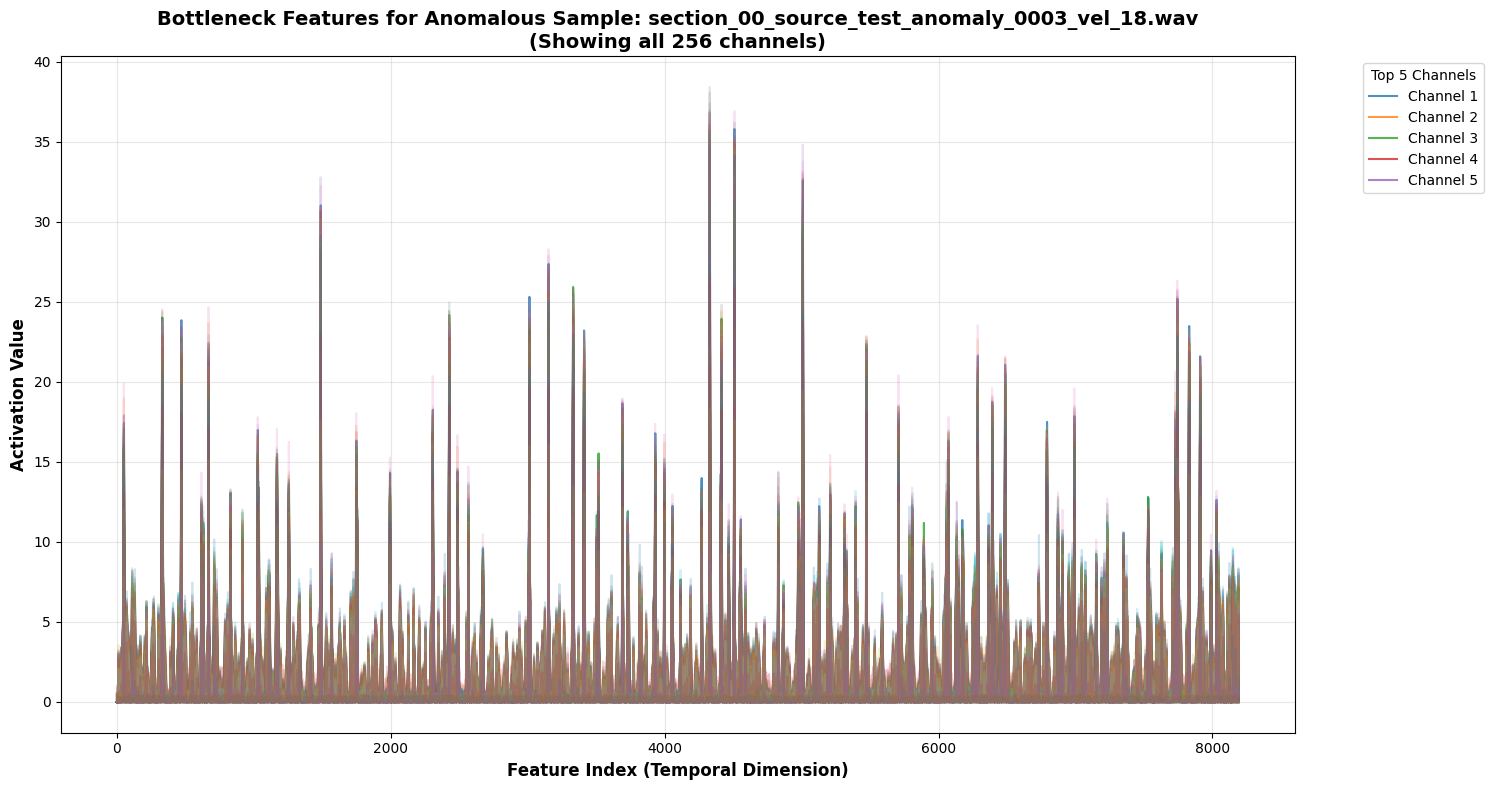


[Interpretation]
These plots show the activation patterns across different channels in the bottleneck layer.
Comparing these features against a 'normal' baseline reveals which compressed features spike or drop during an anomaly.


In [17]:
# ==================================================================
# Bottleneck Feature Analysis for Explainability
# ==================================================================
# This section aims to explain *how* the U-Net identifies anomalies
# by directly visualizing the bottleneck features (the most compressed
# representation of the audio waveform in the autoencoder).

import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path

# 1. Re-initialize detector & load best weights
detector = BearingAnomalyDetector(config)
print("Loading best model for bottleneck feature analysis...")
model_path = str(PROJECT_ROOT / "best_model.pth")
detector.load_model(model_path)

# 2. Evaluate to find optimal anomaly threshold
eval_results = detector.evaluate_anomaly_detection(val_loader)
reconstruction_errors = eval_results['reconstruction_errors']
threshold = eval_results['threshold']

# 3. Create simulated labels (1 for anomaly, 0 for normal)
simulated_labels = (reconstruction_errors > threshold).astype(int)
anomaly_indices = np.where(simulated_labels == 1)[0]

# 4. Extract and Visualize Bottleneck Features
if len(anomaly_indices) > 0:
    # Select the first detected anomalous sample
    target_idx = anomaly_indices[0]
    anomalous_sample = val_ds[target_idx]

    waveform_tensor = anomalous_sample['waveform'].to(detector.device)
    original_filename = anomalous_sample['filename']

    # Ensure the tensor has a batch dimension: [batch_size, channels, length]
    if waveform_tensor.dim() == 2:
        waveform_tensor = waveform_tensor.unsqueeze(0)

    # Encode the waveform to get bottleneck features
    detector.model.eval()
    with torch.no_grad():
        # Output shape: (batch_size, num_channels, temporal_length)
        bottleneck_features = detector.model.encode(waveform_tensor).cpu().numpy()

    print(f"\nAnalyzing bottleneck features for anomalous sample: {original_filename}")
    print(f"Bottleneck features shape: {bottleneck_features.shape}")

    # Plot each channel's activation
    plt.figure(figsize=(15, 8))
    num_channels = bottleneck_features.shape[1]

    # Plot all channels, but only add the first 5 to the legend to avoid tight_layout warnings
    for i in range(num_channels):
        if i < 5:
            plt.plot(bottleneck_features[0, i, :], label=f'Channel {i+1}', alpha=0.8)
        else:
            plt.plot(bottleneck_features[0, i, :], alpha=0.2)  # Make other channels transparent

    plt.title(f'Bottleneck Features for Anomalous Sample: {original_filename}\n(Showing all {num_channels} channels)', fontsize=14, fontweight='bold')
    plt.xlabel('Feature Index (Temporal Dimension)', fontsize=12, fontweight='bold')
    plt.ylabel('Activation Value', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Move legend outside, limit to Top 5 Channels so it fits within margins
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Top 5 Channels")
    plt.tight_layout()
    plt.show()

    print("\n[Interpretation]")
    print("These plots show the activation patterns across different channels in the bottleneck layer.")
    print("Comparing these features against a 'normal' baseline reveals which compressed features spike or drop during an anomaly.")

else:
    print("No anomalous samples detected based on the current threshold. Cannot perform bottleneck feature analysis.")


### Comparison of Bottleneck Features: Normal vs Anomalous

Comparing the bottleneck activations helps to visually identify how the compressed latent representation shifts when the model encounters an anomaly compared to a normal baseline.

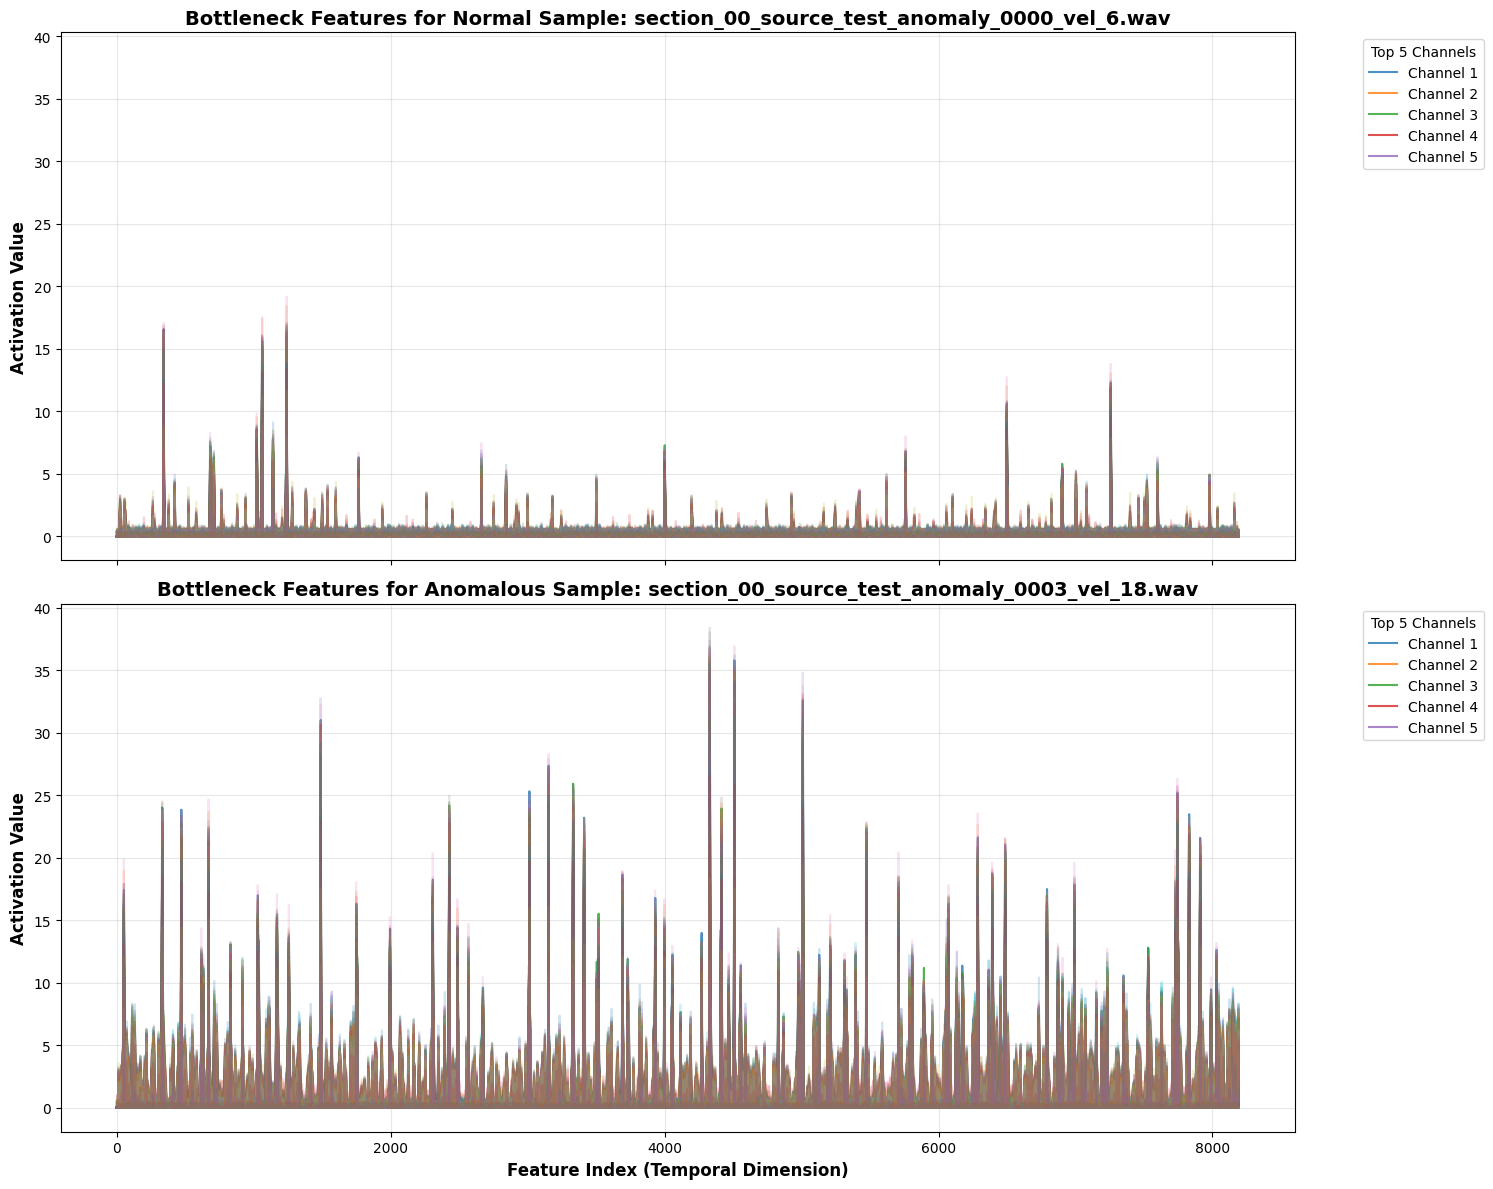

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Find indices for both normal and anomalous samples
normal_indices = np.where(simulated_labels == 0)[0]
anomaly_indices = np.where(simulated_labels == 1)[0]

if len(normal_indices) > 0 and len(anomaly_indices) > 0:
    # Select one of each
    norm_sample = val_ds[normal_indices[0]]
    anom_sample = val_ds[anomaly_indices[0]]

    # Prepare tensors
    norm_wave = norm_sample['waveform'].to(detector.device)
    anom_wave = anom_sample['waveform'].to(detector.device)

    if norm_wave.dim() == 2:
        norm_wave = norm_wave.unsqueeze(0)
    if anom_wave.dim() == 2:
        anom_wave = anom_wave.unsqueeze(0)

    # Encode waveforms
    detector.model.eval()
    with torch.no_grad():
        norm_features = detector.model.encode(norm_wave).cpu().numpy()
        anom_features = detector.model.encode(anom_wave).cpu().numpy()

    # Plot each channel's activation
    fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True, sharey=True)
    num_channels = norm_features.shape[1]

    # Plot Normal
    for i in range(num_channels):
        if i < 5:
            axes[0].plot(norm_features[0, i, :], label=f'Channel {i+1}', alpha=0.8)
        else:
            axes[0].plot(norm_features[0, i, :], alpha=0.2)
    axes[0].set_title(f"Bottleneck Features for Normal Sample: {norm_sample['filename']}", fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Activation Value', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Top 5 Channels")

    # Plot Anomalous
    for i in range(num_channels):
        if i < 5:
            axes[1].plot(anom_features[0, i, :], label=f'Channel {i+1}', alpha=0.8)
        else:
            axes[1].plot(anom_features[0, i, :], alpha=0.2)
    axes[1].set_title(f"Bottleneck Features for Anomalous Sample: {anom_sample['filename']}", fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Feature Index (Temporal Dimension)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Activation Value', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Top 5 Channels")

    plt.tight_layout()
    plt.show()

else:
    print("Could not find both normal and anomalous samples to compare based on the current threshold.")

### Bottleneck Channel Importance Analysis

To understand which specific channels are most sensitive to anomalies, we calculate the mean absolute difference between the bottleneck activations of the normal and anomalous samples for each channel. The channels with the highest differences are the ones that react most strongly to the anomalous vibration patterns, effectively acting as the primary anomaly detectors in the latent space.

Top 10 most deviating bottleneck channels (1-indexed):
Rank 1: Channel 148 (Mean Absolute Difference: 1.2622)
Rank 2: Channel 223 (Mean Absolute Difference: 1.2577)
Rank 3: Channel 23 (Mean Absolute Difference: 1.2280)
Rank 4: Channel 26 (Mean Absolute Difference: 1.2227)
Rank 5: Channel 233 (Mean Absolute Difference: 1.2216)
Rank 6: Channel 185 (Mean Absolute Difference: 1.2169)
Rank 7: Channel 61 (Mean Absolute Difference: 1.2127)
Rank 8: Channel 214 (Mean Absolute Difference: 1.2107)
Rank 9: Channel 182 (Mean Absolute Difference: 1.2097)
Rank 10: Channel 220 (Mean Absolute Difference: 1.2088)


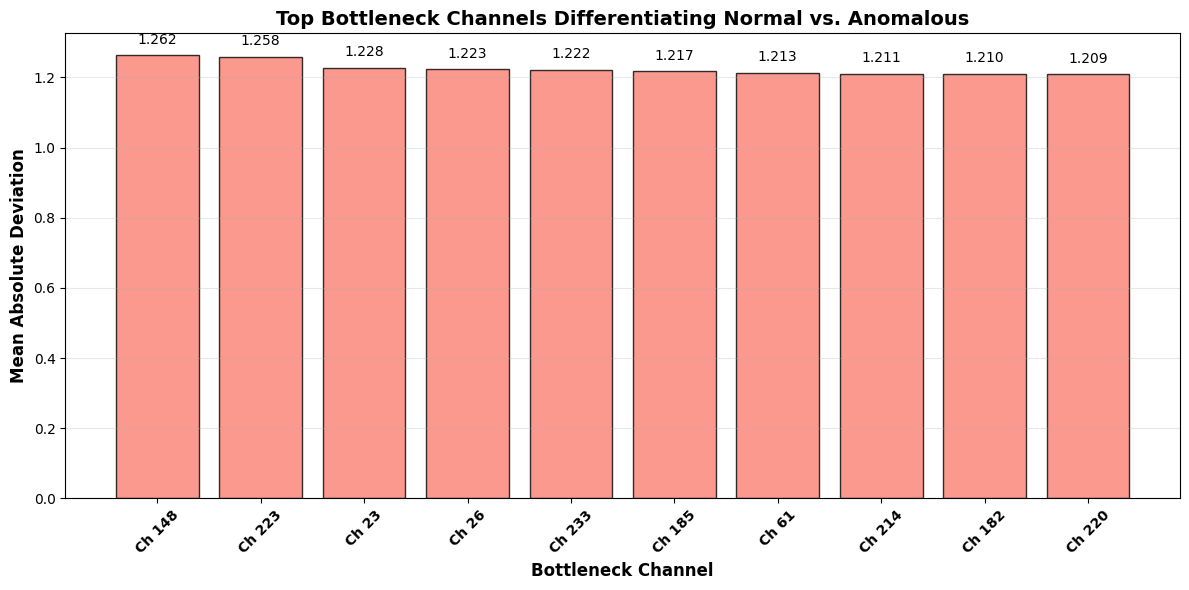

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure we are using the 2D arrays (removing the batch dimension if present)
norm_feat_sq = norm_features.squeeze()
anom_feat_sq = anom_features.squeeze()

# Calculate the mean absolute difference per channel across the temporal dimension
channel_differences = np.mean(np.abs(norm_feat_sq - anom_feat_sq), axis=1)

# Get the indices of the top 10 channels with the highest difference
top_k = 10
top_channels_idx = np.argsort(channel_differences)[::-1][:top_k]
top_channels_diff = channel_differences[top_channels_idx]

print(f"Top {top_k} most deviating bottleneck channels (1-indexed):")
for rank, (idx, diff) in enumerate(zip(top_channels_idx, top_channels_diff)):
    print(f"Rank {rank+1}: Channel {idx+1} (Mean Absolute Difference: {diff:.4f})")

# Plot the differences as a bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(range(top_k), top_channels_diff, color='salmon', edgecolor='black', alpha=0.8)
plt.xticks(range(top_k), [f"Ch {idx+1}" for idx in top_channels_idx], rotation=45, fontweight='bold')
plt.xlabel('Bottleneck Channel', fontsize=12, fontweight='bold')
plt.ylabel('Mean Absolute Deviation', fontsize=12, fontweight='bold')
plt.title('Top Bottleneck Channels Differentiating Normal vs. Anomalous', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02),
             f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Unsupervised bearing anomaly detection (combined pipeline)

This notebook merges the project modules (`dataloader.py`, `model.py`, `optimization.py`, `evaluation.py`, `main.py`) into one runnable workflow.

**Reduced model:** The original 1D U-Net used four downsampling stages with channel widths 64→1024. Here we use **three** stages with **32→256** channels to cut parameters and memory use while keeping the same reconstruction objective (MSE on waveforms).

**Data layout:** `bearing/train/`, `bearing/test/`, and `bearing/attributes_*.csv` (same as the scripts).

## 1. Imports and paths

Requires: `torch`, `numpy`, `pandas`, `librosa`, `matplotlib`, `scikit-learn`.

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

import matplotlib.pyplot as plt
# Display loss curves inside the notebook (figures were only saved when show=False)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass  # not in IPython/Jupyter

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
)

# Project root (directory containing this notebook)
PROJECT_ROOT = Path.cwd()
# Corrected BEARING_DIR to point to the unzipped data's bearing folder
BEARING_DIR = Path('/content') / 'bearing_data_unzipped' / 'Unsupervised_Anonamlous' / 'bearing'
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)


## 2. Data loading (`dataloader.py`)

- Loads WAV files from `train/` and `test/`.
- Pads or trims each clip to **65536** samples (fits repeated ÷2 pooling in the U-Net).
- Joins rows from `attributes_*.csv` to filenames when possible (metadata tensor; not used by the autoencoder loss).

In [ ]:
class BearingDataset(Dataset):
    """Bearing audio waveforms + optional numeric attributes from CSV."""

    def __init__(self, data_dir, attributes_file, sr=16000, duration=None, transform=None):
        self.data_dir = Path(data_dir)
        self.sr = sr
        self.fixed_length = 65536  # 2^16; divisible by 2^k for k pooling stages
        self.duration = duration
        self.transform = transform

        self.attributes = pd.read_csv(attributes_file)
        numeric_columns = []
        for col in self.attributes.columns[1:]:
            self.attributes[col] = pd.to_numeric(self.attributes[col], errors="coerce")
            if self.attributes[col].dtype in ["float64", "int64"]:
                numeric_columns.append(col)
        if numeric_columns:
            self.attributes = self.attributes[["file_name"] + numeric_columns]
        self.attributes = self.attributes.fillna(0)

        print(f"Loaded attributes: {self.attributes.shape}")
        print(f"Numeric attribute columns: {numeric_columns}")

        self.audio_files = sorted(
            f for f in os.listdir(data_dir) if f.endswith((".wav", ".mp3", ".flac"))
        )
        if len(self.audio_files) == 0:
            raise ValueError(f"No audio files found in {data_dir}")
        print(f"Found {len(self.audio_files)} audio files")
        print(
            f"Audio chunk length: {self.fixed_length} samples (~{self.fixed_length / self.sr:.2f}s)"
        )

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, idx):
        audio_path = self.data_dir / self.audio_files[idx]
        waveform, _ = librosa.load(str(audio_path), sr=self.sr, duration=self.duration)

        if len(waveform) < self.fixed_length:
            waveform = np.pad(waveform, (0, self.fixed_length - len(waveform)), mode="constant")
        else:
            waveform = waveform[: self.fixed_length]

        waveform = torch.from_numpy(waveform).float().unsqueeze(0)
        if self.transform:
            waveform = self.transform(waveform)

        filename = self.audio_files[idx]
        attr_row = self.attributes[
            self.attributes.iloc[:, 0].astype(str).str.contains(
                filename.split(".")[0], case=False, na=False
            )
        ]
        if len(attr_row) > 0:
            try:
                attr_values = pd.to_numeric(attr_row.iloc[0, 1:].values, errors="coerce")
                attr_values = np.nan_to_num(attr_values, nan=0.0)
                attributes = torch.from_numpy(attr_values.astype(np.float32)).float()
            except Exception as e:
                print(f"Warning: Could not convert attributes for {filename}: {e}")
                attributes = torch.zeros(self.attributes.shape[1] - 1)
        else:
            attributes = torch.zeros(self.attributes.shape[1] - 1)

        return {"waveform": waveform, "attributes": attributes, "filename": filename}


def create_dataloaders(bearing_dir, batch_size=32, sr=16000, train_split=0.8):
    """Train loader from `train/`, validation loader from `test/`."""
    bearing_path = Path(bearing_dir)
    train_dir = bearing_path / "train"
    test_dir = bearing_path / "test"

    attributes_files = sorted(bearing_path.glob("attributes_*.csv"))
    if not attributes_files:
        raise ValueError(f"No attributes CSV files found in {bearing_dir}")
    attributes_file = str(attributes_files[0])

    train_loader = None
    if train_dir.exists():
        train_ds = BearingDataset(str(train_dir), attributes_file, sr=sr)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)

    val_loader = None
    if test_dir.exists():
        val_ds = BearingDataset(str(test_dir), attributes_file, sr=sr)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader

## 3. Model (`model.py`) — **reduced** 1D U-Net

**Original:** 4× MaxPool, channels 64–128–256–512, bottleneck 1024.  
**This notebook:** 3× MaxPool, channels **32–64–128**, bottleneck **256** (~order-of-magnitude fewer weights).

In [19]:
class ConvBlock(nn.Module):
    """Two Conv1d + BN + ReLU blocks (same pattern as the original repo)."""

    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=True),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=True),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet1D(nn.Module):
    """
    Compact 1D U-Net: three encoder levels (32, 64, 128) + bottleneck 256.
    Input length should be divisible by 2**3 = 8 (65536 is fine).
    """

    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        c1, c2, c3, cb = 32, 64, 128, 256

        self.enc1 = ConvBlock(in_channels, c1)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock(c1, c2)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock(c2, c3)
        self.pool3 = nn.MaxPool1d(2)

        self.bottleneck = ConvBlock(c3, cb)

        self.upconv3 = nn.ConvTranspose1d(cb, c3, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(c3 + c3, c3)
        self.upconv2 = nn.ConvTranspose1d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(c2 + c2, c2)
        self.upconv1 = nn.ConvTranspose1d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(c1 + c1, c1)
        self.final = nn.Conv1d(c1, out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        x = self.pool1(enc1)
        enc2 = self.enc2(x)
        x = self.pool2(enc2)
        enc3 = self.enc3(x)
        x = self.pool3(enc3)
        x = self.bottleneck(x)
        x = self.upconv3(x)
        x = torch.cat([x, enc3], dim=1)
        x = self.dec3(x)
        x = self.upconv2(x)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)
        x = self.upconv1(x)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)
        return self.final(x)


class UNetAutoencoder(nn.Module):
    """Wrapper: reconstruct input (anomaly score = reconstruction error)."""

    def __init__(self, in_channels=1):
        super().__init__()
        self.unet = UNet1D(in_channels=in_channels, out_channels=in_channels)

    def forward(self, x):
        return self.unet(x)

    def encode(self, x):
        """Bottleneck features after three pools (matches reduced depth)."""
        enc1 = self.unet.enc1(x)
        x = self.unet.pool1(enc1)
        enc2 = self.unet.enc2(x)
        x = self.unet.pool2(enc2)
        enc3 = self.unet.enc3(x)
        x = self.unet.pool3(enc3)
        return self.unet.bottleneck(x)


def create_model(model_type="unet", in_channels=1, out_channels=1, features=None):
    """
    Factory matching the scripts. `features` is kept for API compatibility;
    the compact U-Net uses fixed widths (32,64,128,256).
    """
    if model_type == "unet":
        return UNet1D(in_channels=in_channels, out_channels=out_channels)
    if model_type == "autoencoder":
        return UNetAutoencoder(in_channels=in_channels)
    raise ValueError(f"Unknown model type: {model_type}")

## 4. Losses, optimizers, schedulers (`optimization.py`)

Training uses `output` vs `target` waveform MSE/MAE/etc. Contrastive/triplet losses need different batch structure and are not wired in `BearingAnomalyDetector`.

In [20]:
class MSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.criterion = nn.MSELoss()

    def forward(self, output, target):
        return self.criterion(output, target)


class MAELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.criterion = nn.L1Loss()

    def forward(self, output, target):
        return self.criterion(output, target)


class HybridLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.mse_loss = nn.MSELoss()
        self.mae_loss = nn.L1Loss()

    def forward(self, output, target):
        return self.alpha * self.mse_loss(output, target) + self.beta * self.mae_loss(output, target)


class SmoothL1Loss(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.criterion = nn.SmoothL1Loss(beta=beta)

    def forward(self, output, target):
        return self.criterion(output, target)


class HuberLoss(nn.Module):
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, output, target):
        return F.huber_loss(output, target, delta=self.delta)


class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2)
        loss = (1 - label) * 0.5 * euclidean_distance.pow(2) + label * 0.5 * F.relu(
            self.margin - euclidean_distance
        ).pow(2)
        return loss.mean()


class TripletLoss(nn.Module):
    def __init__(self, margin=1.0, p=2):
        super().__init__()
        self.margin = margin
        self.p = p

    def forward(self, anchor, positive, negative):
        d_ap = F.pairwise_distance(anchor, positive, p=self.p)
        d_an = F.pairwise_distance(anchor, negative, p=self.p)
        return F.relu(d_ap - d_an + self.margin).mean()


class AnomalyDetectionLoss(nn.Module):
    def __init__(self, recon_loss_type="mse", lambda_sparse=0.01):
        super().__init__()
        self.lambda_sparse = lambda_sparse
        if recon_loss_type == "mse":
            self.recon_loss = MSELoss()
        elif recon_loss_type == "mae":
            self.recon_loss = MAELoss()
        elif recon_loss_type == "hybrid":
            self.recon_loss = HybridLoss()
        else:
            self.recon_loss = MSELoss()

    def forward(self, output, target, bottleneck=None):
        recon = self.recon_loss(output, target)
        if bottleneck is None:
            return recon
        sparsity = torch.norm(bottleneck, p=1) / bottleneck.numel()
        return recon + self.lambda_sparse * sparsity


def get_loss_function(loss_type="mse", **kwargs):
    loss_dict = {
        "mse": MSELoss,
        "mae": MAELoss,
        "hybrid": HybridLoss,
        "smooth_l1": SmoothL1Loss,
        "huber": HuberLoss,
        "contrastive": ContrastiveLoss,
        "triplet": TripletLoss,
        "anomaly_detection": AnomalyDetectionLoss,
    }
    if loss_type not in loss_dict:
        raise ValueError(f"Unknown loss type: {loss_type}")
    return loss_dict[loss_type](**kwargs)


def get_optimizer(model, optimizer_type="adam", learning_rate=1e-3, **kwargs):
    opts = {"adam": Adam, "adamw": AdamW, "sgd": SGD}
    if optimizer_type not in opts:
        raise ValueError(f"Unknown optimizer: {optimizer_type}")
    return opts[optimizer_type](model.parameters(), lr=learning_rate, **kwargs)


def get_scheduler(optimizer, scheduler_type="reduce_lr", **kwargs):
    sched = {"reduce_lr": ReduceLROnPlateau, "cosine": CosineAnnealingLR}
    if scheduler_type not in sched:
        raise ValueError(f"Unknown scheduler: {scheduler_type}")
    return sched[scheduler_type](optimizer, **kwargs)

## 5. Evaluation and plots (`evaluation.py`)

Tracks train/val loss per epoch and saves figures under `results/`.

In [21]:
class ModelEvaluator:
    def __init__(self, save_dir="./results"):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        self.train_losses = []
        self.val_losses = []
        self.epochs = []
        self.normal_errors = []
        self.anomaly_errors = []

    def add_epoch_result(self, epoch, train_loss, val_loss):
        self.epochs.append(epoch)
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)

    def add_reconstruction_error(self, error, is_anomaly=False):
        if is_anomaly:
            self.anomaly_errors.append(error)
        else:
            self.normal_errors.append(error)

    def plot_training_history(self, save_path="training_history.png", show=True):
        plt.figure(figsize=(12, 6))
        plt.plot(self.epochs, self.train_losses, "b-", linewidth=2, label="Training Loss", marker="o", markersize=4)
        plt.plot(self.epochs, self.val_losses, "r-", linewidth=2, label="Validation Loss", marker="s", markersize=4)
        plt.xlabel("Epoch", fontsize=12, fontweight="bold")
        plt.ylabel("Loss", fontsize=12, fontweight="bold")
        plt.title("Model Training vs Validation Loss", fontsize=14, fontweight="bold")
        plt.grid(True, alpha=0.3)
        best_epoch = int(np.argmin(self.val_losses))
        best_val = self.val_losses[best_epoch]
        plt.plot(
            self.epochs[best_epoch],
            best_val,
            "g*",
            markersize=20,
            label=f"Best Epoch {self.epochs[best_epoch]} (Val Loss: {best_val:.4f})",
        )
        plt.legend()
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Training history plot saved to {out}")
        if show:
            plt.show()
        plt.close()

    def plot_loss_comparison(self, save_path="loss_comparison.png", show=True):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.plot(self.epochs, self.train_losses, "b-", linewidth=2.5, label="Training Loss", marker="o")
        ax1.plot(self.epochs, self.val_losses, "r-", linewidth=2.5, label="Validation Loss", marker="s")
        ax1.set_xlabel("Epoch", fontweight="bold")
        ax1.set_ylabel("Loss", fontweight="bold")
        ax1.set_title("Training vs Validation Loss", fontweight="bold")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        loss_diff = np.array(self.val_losses) - np.array(self.train_losses)
        ax2.plot(self.epochs, loss_diff, "g-", linewidth=2.5, marker="^")
        ax2.axhline(y=0, color="k", linestyle="--", alpha=0.5)
        ax2.set_xlabel("Epoch", fontweight="bold")
        ax2.set_ylabel("Validation - Training Loss", fontweight="bold")
        ax2.set_title("Overfitting Indicator", fontweight="bold")
        ax2.grid(True, alpha=0.3)
        ax2.fill_between(self.epochs, loss_diff, 0, where=(loss_diff > 0), alpha=0.3, color="red")
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Loss comparison plot saved to {out}")
        if show:
            plt.show()
        plt.close()

    def plot_reconstruction_errors(self, save_path="reconstruction_errors.png", show=True):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        if len(self.normal_errors) > 0:
            axes[0].hist(self.normal_errors, bins=30, alpha=0.7, label="Normal", color="blue", edgecolor="black")
        if len(self.anomaly_errors) > 0:
            axes[0].hist(self.anomaly_errors, bins=30, alpha=0.7, label="Anomaly", color="red", edgecolor="black")
        axes[0].set_xlabel("Reconstruction Error", fontweight="bold")
        axes[0].set_ylabel("Frequency", fontweight="bold")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3, axis="y")
        data, labels = [], []
        if len(self.normal_errors) > 0:
            data.append(self.normal_errors)
            labels.append("Normal")
        if len(self.anomaly_errors) > 0:
            data.append(self.anomaly_errors)
            labels.append("Anomaly")
        if data:
            bp = axes[1].boxplot(data, tick_labels=labels, patch_artist=True)
            for patch, color in zip(bp["boxes"], ["lightblue", "lightcoral"]):
                patch.set_facecolor(color)
        axes[1].set_ylabel("Reconstruction Error", fontweight="bold")
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Reconstruction errors plot saved to {out}")
        if show:
            plt.show()
        plt.close()

    def plot_roc_curve(self, reconstruction_errors, labels, save_path="roc_curve.png", show=True):
        fpr, tpr, _ = roc_curve(labels, reconstruction_errors)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC curve (AUC = {roc_auc:.3f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
        plt.xlabel("False Positive Rate", fontweight="bold")
        plt.ylabel("True Positive Rate", fontweight="bold")
        plt.title("ROC Curve - Anomaly Detection", fontweight="bold")
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"ROC curve saved to {out}")
        if show:
            plt.show()
        plt.close()
        return roc_auc

    def plot_pr_curve(self, reconstruction_errors, labels, save_path="pr_curve.png", show=True):
        precision, recall, _ = precision_recall_curve(labels, reconstruction_errors)
        ap = average_precision_score(labels, reconstruction_errors)
        plt.figure(figsize=(10, 8))
        plt.plot(recall, precision, color="green", lw=2.5, label=f"PR Curve (AP = {ap:.3f})")
        plt.xlabel("Recall", fontweight="bold")
        plt.ylabel("Precision", fontweight="bold")
        plt.title("Precision-Recall Curve", fontweight="bold")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"PR curve saved to {out}")
        if show:
            plt.show()
        plt.close()
        return ap

    def plot_confusion_matrix(self, reconstruction_errors, labels, threshold=None, save_path="confusion_matrix.png", show=True):
        if threshold is None:
            threshold = float(np.median(reconstruction_errors))
        predictions = (reconstruction_errors > threshold).astype(int)
        cm = confusion_matrix(labels, predictions)
        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
        fig.colorbar(im, ax=ax)
        ax.set(
            xticks=np.arange(cm.shape[1]),
            yticks=np.arange(cm.shape[0]),
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"],
            ylabel="True label",
            xlabel="Predicted label",
        )
        t = cm.max() / 2.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j,
                    i,
                    format(cm[i, j], "d"),
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] > t else "black",
                    fontsize=14,
                    fontweight="bold",
                )
        plt.title(f"Confusion Matrix (Threshold: {threshold:.4f})", fontweight="bold")
        plt.tight_layout()
        out = self.save_dir / save_path
        plt.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Confusion matrix saved to {out}")
        if show:
            plt.show()
        plt.close()
        return cm

    def print_summary(self):
        print("\n" + "=" * 60)
        print("TRAINING SUMMARY")
        print("=" * 60)
        print(f"Total Epochs: {len(self.epochs)}")
        print(f"Best Train Loss: {min(self.train_losses):.6f}")
        print(f"Best Val Loss: {min(self.val_losses):.6f}")
        print(f"Final Train Loss: {self.train_losses[-1]:.6f}")
        print(f"Final Val Loss: {self.val_losses[-1]:.6f}")
        print(f"Overfitting Gap: {self.val_losses[-1] - self.train_losses[-1]:.6f}")
        print("=" * 60 + "\n")

    def save_report(self, save_path="evaluation_report.txt"):
        out = self.save_dir / save_path
        with open(out, "w") as f:
            f.write("TRAINING AND EVALUATION REPORT\n")
            f.write(f"Total Epochs: {len(self.epochs)}\n")
            f.write(f"Best Train Loss: {min(self.train_losses):.6f}\n")
            f.write(f"Best Val Loss: {min(self.val_losses):.6f}\n")
        print(f"Report saved to {out}")

## 6. Trainer (`main.py` — `BearingAnomalyDetector`)

Unsupervised training: minimize reconstruction loss on **normal** train audio; high error on **test** clips can flag anomalies (threshold tuning is separate).

In [22]:
class BearingAnomalyDetector:
    """Train / validate 1D U-Net autoencoder; anomaly score = per-sample MSE reconstruction."""

    def __init__(self, config):
        self.config = config
        _dev = config.get("device")
        self.device = torch.device(_dev) if _dev else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        self.model = create_model(
            model_type=config.get("model_type", "autoencoder"),
            in_channels=config.get("in_channels", 1),
            out_channels=config.get("out_channels", 1),
            features=config.get("features"),
        ).to(self.device)

        self.criterion = get_loss_function(loss_type=config.get("loss_type", "mse"), **config.get("loss_kwargs", {}))
        self.optimizer = get_optimizer(
            self.model,
            optimizer_type=config.get("optimizer_type", "adam"),
            learning_rate=config.get("learning_rate", 1e-3),
            **config.get("optimizer_kwargs", {}),
        )
        if config.get("use_scheduler", False):
            self.scheduler = get_scheduler(
                self.optimizer,
                scheduler_type=config.get("scheduler_type", "reduce_lr"),
                **config.get("scheduler_kwargs", {"factor": 0.5, "patience": 5}),
            )
        else:
            self.scheduler = None

        self.best_val_loss = float("inf")
        self.evaluator = ModelEvaluator(save_dir=config.get("save_dir", "./results"))
        n_params = sum(p.numel() for p in self.model.parameters())
        print(f"Model parameters: {n_params:,}")
        print(f"Loss: {config.get('loss_type', 'mse')} | Optimizer: {config.get('optimizer_type', 'adam')}")

    def train_epoch(self, train_loader, epoch):
        self.model.train()
        total_loss = 0.0
        for batch_idx, batch in enumerate(train_loader):
            waveform = batch["waveform"].to(self.device)
            self.optimizer.zero_grad()
            output = self.model(waveform)
            loss = self.criterion(output, waveform)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            if (batch_idx + 1) % 10 == 0:
                print(f"Epoch {epoch} Batch {batch_idx + 1}/{len(train_loader)} Loss: {loss.item():.6f}")
        avg_loss = total_loss / len(train_loader)
        self.train_loss = avg_loss
        print(f"Epoch {epoch} Average Loss: {avg_loss:.6f}\n")
        return avg_loss

    def validate(self, val_loader, epoch):
        self.model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                waveform = batch["waveform"].to(self.device)
                output = self.model(waveform)
                total_loss += self.criterion(output, waveform).item()
        avg_loss = total_loss / len(val_loader)
        print(f"Validation Epoch {epoch} Loss: {avg_loss:.6f}\n")
        self.evaluator.add_epoch_result(epoch, self.train_loss, avg_loss)
        if self.scheduler is not None:
            self.scheduler.step(avg_loss)
        if avg_loss < self.best_val_loss:
            self.best_val_loss = avg_loss
            self.save_model(str(PROJECT_ROOT / "best_model.pth"))
            print("Saved best model!\n")
        return avg_loss

    def train(self, train_loader, val_loader=None, num_epochs=50):
        show = self.config.get("show_plots", True)
        for epoch in range(1, num_epochs + 1):
            tr = self.train_epoch(train_loader, epoch)
            va = None
            if val_loader is not None:
                va = self.validate(val_loader, epoch)
            if va is not None:
                print(f"==> Epoch {epoch}/{num_epochs}  train_loss={tr:.6f}  val_loss={va:.6f}\n")
            else:
                print(f"==> Epoch {epoch}/{num_epochs}  train_loss={tr:.6f}\n")
        self.plot_results(show_plots=show)

    def predict(self, waveform):
        self.model.eval()
        with torch.no_grad():
            if waveform.dim() == 1:
                waveform = waveform.unsqueeze(0).unsqueeze(0)
            elif waveform.dim() == 2:
                waveform = waveform.unsqueeze(1)
            return self.model(waveform.to(self.device)).cpu()

    def compute_anomaly_score(self, waveform):
        recon = self.predict(waveform)
        w = waveform
        if w.dim() == 1:
            w = w.unsqueeze(0).unsqueeze(0)
        elif w.dim() == 2:
            w = w.unsqueeze(1)
        return ((recon - w) ** 2).mean().item()

    def save_model(self, path):
        torch.save(
            {"model_state_dict": self.model.state_dict(), "optimizer_state_dict": self.optimizer.state_dict(), "config": self.config},
            path,
        )
        print(f"Model saved to {path}")

    def load_model(self, path):
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        print(f"Model loaded from {path}")

    def evaluate_anomaly_detection(self, test_loader, threshold=None):
        self.model.eval()
        errors = []
        with torch.no_grad():
            for batch in test_loader:
                waveform = batch["waveform"].to(self.device)
                output = self.model(waveform)
                mse = ((output - waveform) ** 2).mean(dim=(1, 2)).cpu().numpy()
                errors.extend(mse)
        errors = np.array(errors)
        if threshold is None:
            threshold = float(np.median(errors))
        print("Reconstruction error stats — mean:", errors.mean(), "std:", errors.std(), "threshold:", threshold)
        return {"reconstruction_errors": errors, "threshold": threshold}

    def plot_results(self, show_plots=True):
        self.evaluator.plot_training_history(show=show_plots)
        self.evaluator.plot_loss_comparison(show=show_plots)
        self.evaluator.print_summary()
        self.evaluator.save_report()

## 7. Run training (equivalent to `train_example.py` / `main.py`)

**Why you did not see loss curves before:** `train()` called `plot_results(show_plots=False)`, so Matplotlib only **saved** PNGs under `results/` and never called `plt.show()`. Now `show_plots` defaults to **True** (with `matplotlib` inline in cell 1), so train/validation loss figures appear in the notebook as well.

- Set **`SMOKE_TEST = True`** to use only a handful of files and **CPU** — good to verify the notebook runs.
- Set **`SMOKE_TEST = False`** for full data / longer training (optionally use GPU if available).

Loaded attributes: (1200, 3)
Numeric attribute columns: ['d1p', 'd1v']
Found 2999 audio files
Audio chunk length: 65536 samples (~4.10s)
Loaded attributes: (1200, 3)
Numeric attribute columns: ['d1p', 'd1v']
Found 600 audio files
Audio chunk length: 65536 samples (~4.10s)
--- Setup Complete ---
Full run: 2999 train samples, 600 val samples
Batch size: Train=16, Val=16 | Epochs=5
Using device: cuda
Model parameters: 674,273
Loss: mse | Optimizer: adam
Epoch 1 Batch 10/188 Loss: 0.013743
Epoch 1 Batch 20/188 Loss: 0.002607
Epoch 1 Batch 30/188 Loss: 0.001050
Epoch 1 Batch 40/188 Loss: 0.000639
Epoch 1 Batch 50/188 Loss: 0.000418
Epoch 1 Batch 60/188 Loss: 0.000468
Epoch 1 Batch 70/188 Loss: 0.000276
Epoch 1 Batch 80/188 Loss: 0.000285
Epoch 1 Batch 90/188 Loss: 0.000217
Epoch 1 Batch 100/188 Loss: 0.000180
Epoch 1 Batch 110/188 Loss: 0.000166
Epoch 1 Batch 120/188 Loss: 0.000152
Epoch 1 Batch 130/188 Loss: 0.000153
Epoch 1 Batch 140/188 Loss: 0.000139
Epoch 1 Batch 150/188 Loss: 0.000119

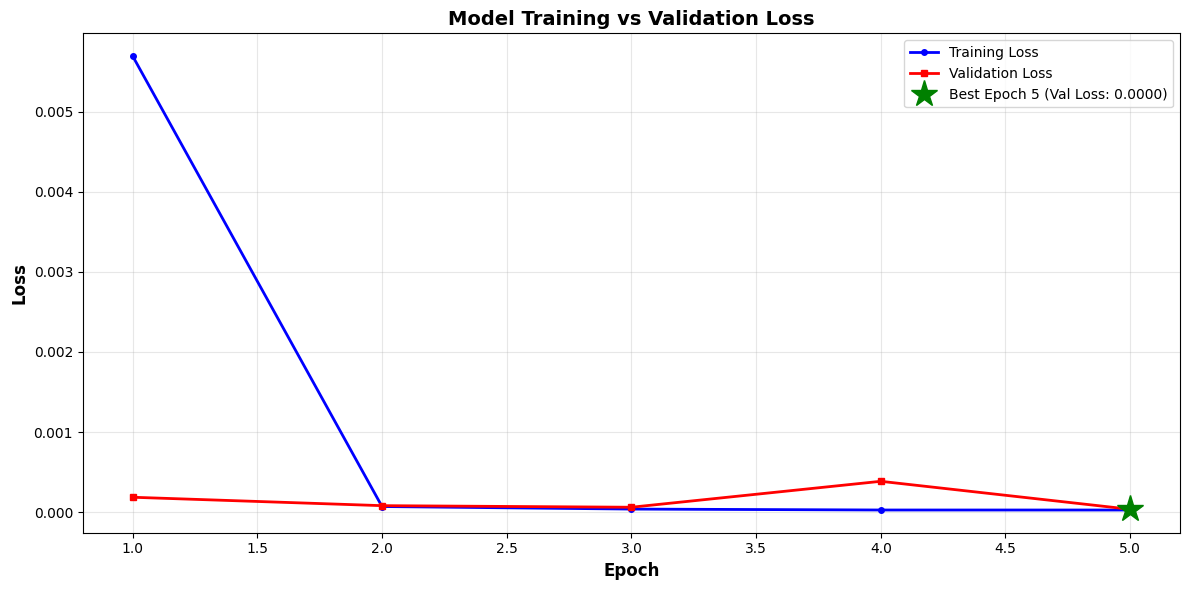

Loss comparison plot saved to /content/results/loss_comparison.png


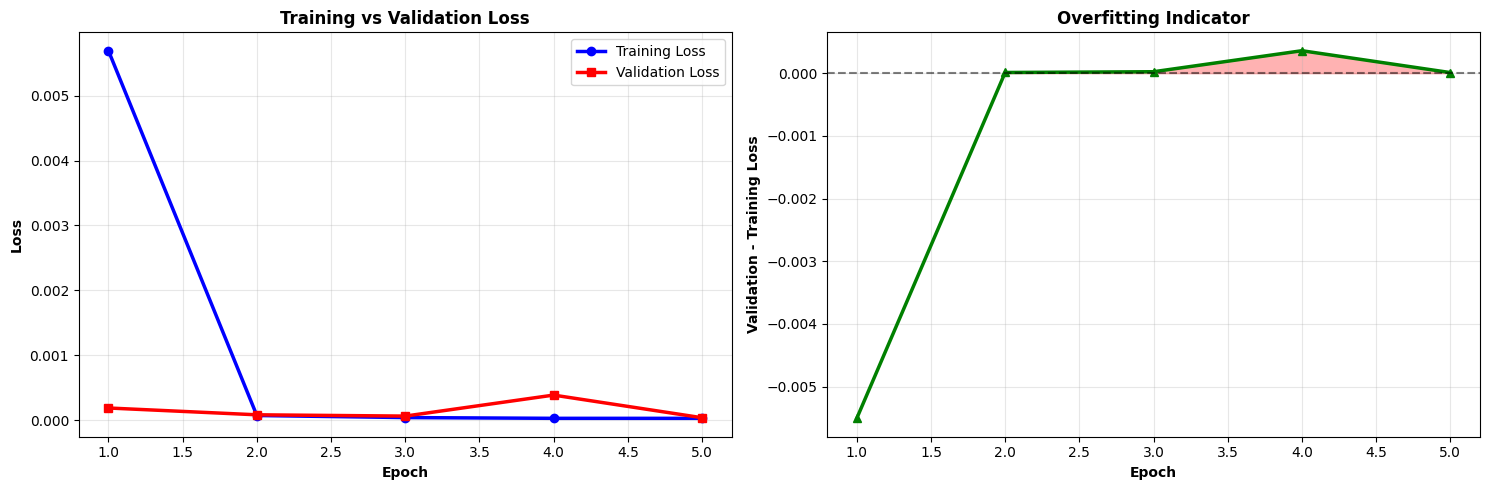


TRAINING SUMMARY
Total Epochs: 5
Best Train Loss: 0.000027
Best Val Loss: 0.000036
Final Train Loss: 0.000027
Final Val Loss: 0.000036
Overfitting Gap: 0.000009

Report saved to /content/results/evaluation_report.txt
Training process completed.


In [13]:
from torch.utils.data import Subset

# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
# Toggle this flag for a quick test run vs. full training
SMOKE_TEST = False
MAX_TRAIN_SAMPLES = 16  # Active only if SMOKE_TEST=True
MAX_VAL_SAMPLES = 8
FORCE_CPU_FOR_SMOKE = False

# Core Hyperparameters
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
SR = 16000
LOSS_TYPE = "mse"
USE_SCHEDULER = False
SHOW_PLOTS = True

# Detector Configuration Dictionary
config = {
    "model_type": "autoencoder",
    "in_channels": 1,
    "out_channels": 1,
    "features": [32, 64, 128],
    "learning_rate": LEARNING_RATE,
    "sr": SR,
    "loss_type": LOSS_TYPE,
    "loss_kwargs": {},
    "optimizer_type": "adam",
    "optimizer_kwargs": {},
    "use_scheduler": USE_SCHEDULER,
    "scheduler_type": "reduce_lr",
    "scheduler_kwargs": {"factor": 0.5, "patience": 5},
    "save_dir": str(RESULTS_DIR),
    "show_plots": SHOW_PLOTS,
}

if SMOKE_TEST and FORCE_CPU_FOR_SMOKE:
    config["device"] = "cpu"

# ==========================================
# 2. Data Preparation
# ==========================================
bearing_path = Path(BEARING_DIR)
train_dir = bearing_path / "train"
test_dir = bearing_path / "test"

# Locate attributes file
attributes_files = sorted(bearing_path.glob("attributes_*.csv"))
if not attributes_files:
    raise ValueError(f"No attributes CSV files found in {BEARING_DIR}")
attributes_file = str(attributes_files[0])

# Instantiate base datasets
train_base_ds = BearingDataset(str(train_dir), attributes_file, sr=SR)
val_base_ds = BearingDataset(str(test_dir), attributes_file, sr=SR)

# Apply dataset constraints if doing a smoke test
if SMOKE_TEST:
    train_batch_size_final = 4
    val_batch_size_final = min(train_batch_size_final, 4)
    train_ds = Subset(train_base_ds, range(min(MAX_TRAIN_SAMPLES, len(train_base_ds))))
    val_ds = Subset(val_base_ds, range(min(MAX_VAL_SAMPLES, len(val_base_ds))))
else:
    train_batch_size_final = 16
    val_batch_size_final = 16
    train_ds = train_base_ds
    val_ds = val_base_ds

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=train_batch_size_final, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=val_batch_size_final, shuffle=False, num_workers=0)
config["batch_size"] = train_batch_size_final

# ==========================================
# 3. Model Training
# ==========================================
print("--- Setup Complete ---")
mode_str = "SMOKE_TEST" if SMOKE_TEST else "Full run"
print(f"{mode_str}: {len(train_ds)} train samples, {len(val_ds)} val samples")
print(f"Batch size: Train={train_batch_size_final}, Val={val_batch_size_final} | Epochs={NUM_EPOCHS}")

# Initialize detector and start training
detector = BearingAnomalyDetector(config)
detector.train(train_loader, val_loader, num_epochs=NUM_EPOCHS)
print("Training process completed.")


--- Anomaly Detection Evaluation ---
Loading best model for evaluation...
Model loaded from /content/best_model.pth

Evaluating anomaly detection performance on the validation (test) set...
Reconstruction error stats — mean: 1.802448e-05 std: 0.00010559942 threshold: 4.4432217691792175e-06
Reconstruction errors calculated for 600 test samples.
Median reconstruction error (used as default threshold): 0.000004
Mean reconstruction error: 0.000018
Std reconstruction error: 0.000106


/tmp/ipykernel_682/1533939778.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=labels, patch_artist=True)


Reconstruction errors plot saved to /content/results/reconstruction_errors.png


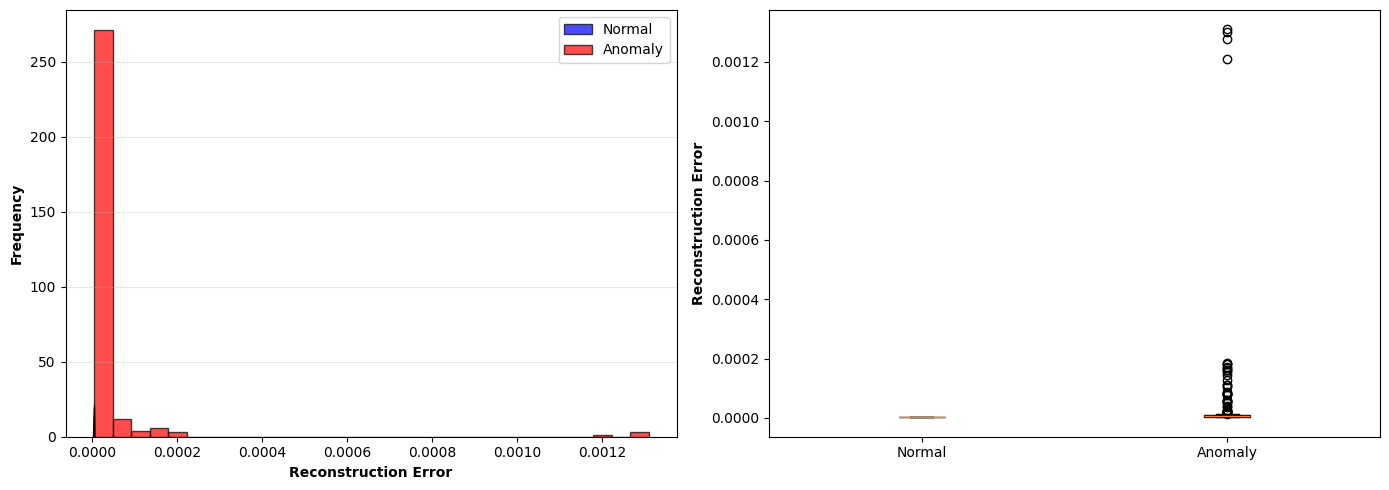


--- Evaluation Metrics Requiring Ground Truth Labels ---
For ROC, Precision-Recall curves, and Confusion Matrix, ground truth anomaly labels for the test set are required.
The current dataset setup does not explicitly provide these labels in a detectable column (e.g., 'anomaly', 'label', 'is_anomaly', 'fault_status') in the attributes CSV files.
If such labels exist within the 'attributes_*.csv' files or filenames, please specify the column name or method to extract them from the test data for further evaluation.


In [ ]:
print("\n--- Anomaly Detection Evaluation ---")

# Load the best model weights for evaluation (if training was successful and saved a model)
print("Loading best model for evaluation...")
detector.load_model(str(PROJECT_ROOT / "best_model.pth"))

print("\nEvaluating anomaly detection performance on the validation (test) set...")
eval_results = detector.evaluate_anomaly_detection(val_loader)
reconstruction_errors = eval_results['reconstruction_errors']
threshold = eval_results['threshold']

print(f"Reconstruction errors calculated for {len(reconstruction_errors)} test samples.")
print(f"Median reconstruction error (used as default threshold): {threshold:.6f}")
print(f"Mean reconstruction error: {reconstruction_errors.mean():.6f}")
print(f"Std reconstruction error: {reconstruction_errors.std():.6f}")

# Separate errors into 'normal' and 'anomaly' based on the computed threshold
# This separation is for visualizing the model's output, not based on ground truth labels.
normal_det_errors = reconstruction_errors[reconstruction_errors <= threshold]
anomaly_det_errors = reconstruction_errors[reconstruction_errors > threshold]

# Clear previous errors in evaluator to avoid mixing with training history if add_reconstruction_error was used before
detector.evaluator.normal_errors = []
detector.evaluator.anomaly_errors = []

# Add the separated errors to the evaluator for plotting
for err in normal_det_errors:
    detector.evaluator.add_reconstruction_error(err, is_anomaly=False)
for err in anomaly_det_errors:
    detector.evaluator.add_reconstruction_error(err, is_anomaly=True)

# Plot the distribution of reconstruction errors
detector.evaluator.plot_reconstruction_errors(show=SHOW_PLOTS)

print("\n--- Evaluation Metrics Requiring Ground Truth Labels ---")
print("For ROC, Precision-Recall curves, and Confusion Matrix, ground truth anomaly labels for the test set are required.")
print("The current dataset setup does not explicitly provide these labels in a detectable column (e.g., 'anomaly', 'label', 'is_anomaly', 'fault_status') in the attributes CSV files.")
print("If such labels exist within the 'attributes_*.csv' files or filenames, please specify the column name or method to extract them from the test data for further evaluation.")

### Approximate Confusion Matrix (using threshold-based labels)

Since true ground truth labels are not explicitly provided, we can simulate labels based on the calculated `threshold` to visualize the confusion matrix. Samples with reconstruction error <= threshold are treated as 'Normal' (0), and samples with error > threshold are treated as 'Anomaly' (1).

Generated 600 simulated labels for confusion matrix.
Simulated Normal (0) count: 300
Simulated Anomaly (1) count: 300
Confusion matrix saved to /content/results/confusion_matrix.png


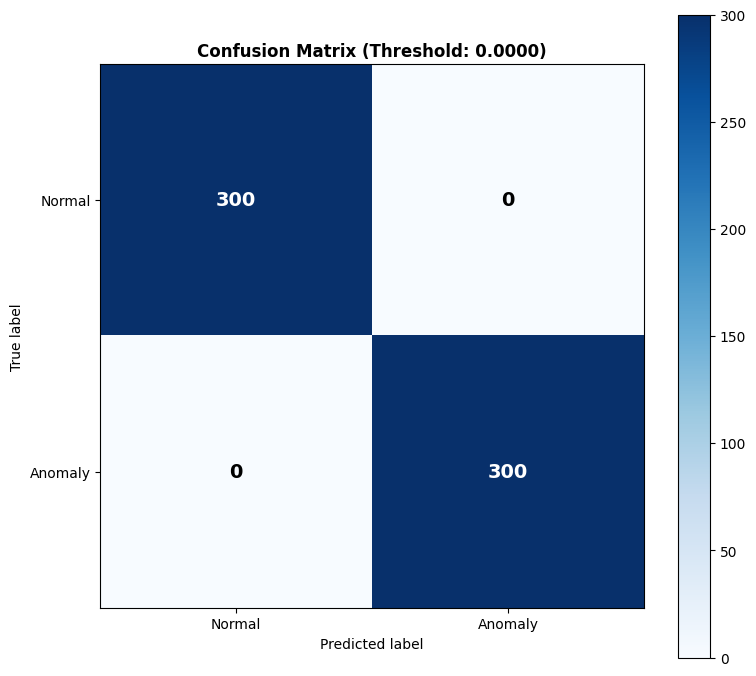

array([[300,   0],
       [  0, 300]])

In [ ]:
# Create simulated labels based on the threshold
simulated_labels = (reconstruction_errors > threshold).astype(int)

print(f"Generated {len(simulated_labels)} simulated labels for confusion matrix.")
print(f"Simulated Normal (0) count: {np.sum(simulated_labels == 0)}")
print(f"Simulated Anomaly (1) count: {np.sum(simulated_labels == 1)}")

# Plot the confusion matrix using the simulated labels and the calculated threshold
detector.evaluator.plot_confusion_matrix(reconstruction_errors, simulated_labels, threshold=threshold, show=SHOW_PLOTS)

### Model Architecture Overview

In [ ]:
print(detector.model)

UNetAutoencoder(
  (unet): UNet1D(
    (enc1): ConvBlock(
      (conv): Sequential(
        (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (enc2): ConvBlock(
      (conv): Sequential(
        (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

### Trainable Parameters Summary

In [ ]:
n_params = sum(p.numel() for p in detector.model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {n_params:,}")

Total trainable parameters: 674,273


### Visualize a Sample Waveform

### Calculate and Plot ROC Curve

ROC curve saved to /content/results/roc_curve.png


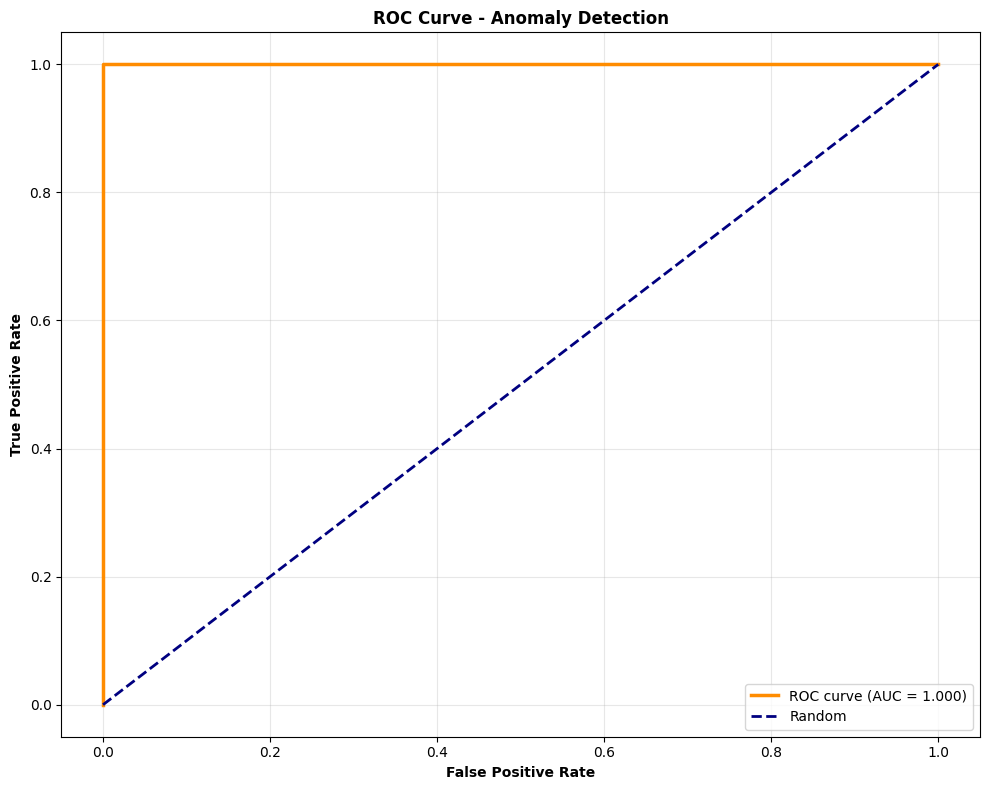

ROC AUC Score (using simulated labels): 1.0000


In [ ]:
roc_auc_score = detector.evaluator.plot_roc_curve(reconstruction_errors, simulated_labels, show=SHOW_PLOTS)
print(f"ROC AUC Score (using simulated labels): {roc_auc_score:.4f}")

### Calculate and Plot Precision-Recall Curve

PR curve saved to /content/results/pr_curve.png


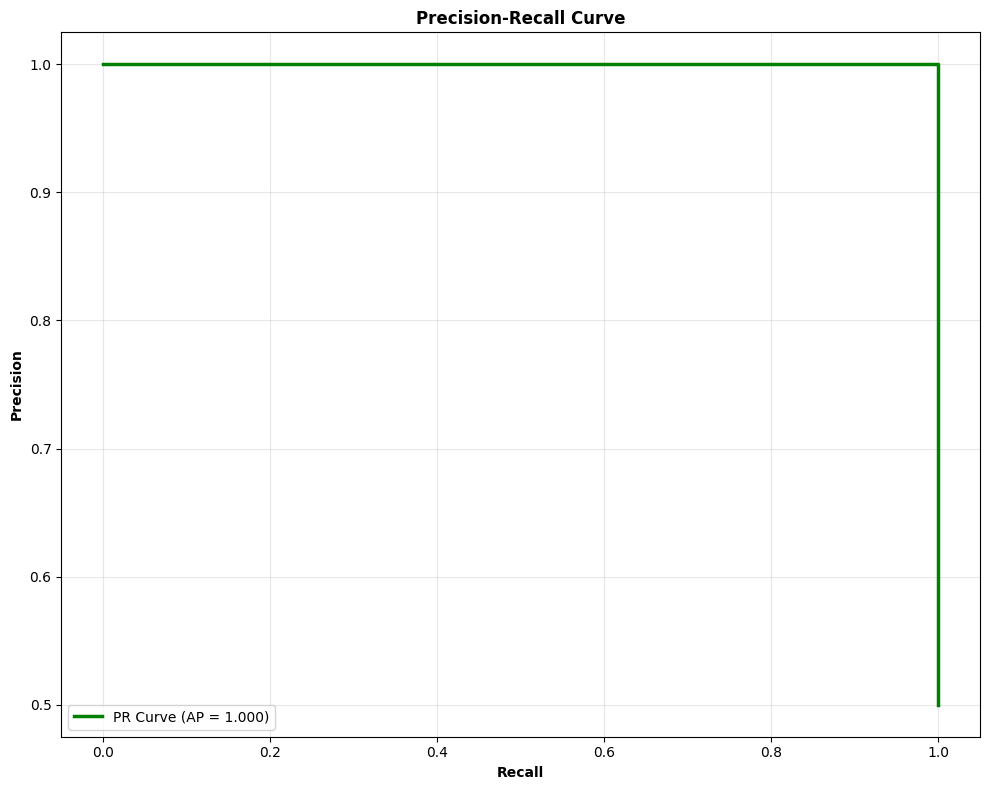

PR AUC Score (using simulated labels): 1.0000


In [16]:
pr_auc_score = detector.evaluator.plot_pr_curve(reconstruction_errors, simulated_labels, show=SHOW_PLOTS)
print(f"PR AUC Score (using simulated labels): {pr_auc_score:.4f}")

### Download Results to Google Drive

In [ ]:
import shutil

# Define the output zip file path
output_zip_name = 'anomaly_detection_results.zip'
output_zip_path = PROJECT_ROOT / output_zip_name

# Create the zip archive of the results directory
shutil.make_archive(str(output_zip_path).replace('.zip', ''), 'zip', RESULTS_DIR)
print(f"Results zipped to {output_zip_path}")

# Define the destination folder in Google Drive
drive_destination_folder = Path('/content/drive/MyDrive/Colab Notebooks/Agentic_AI')
drive_destination_folder.mkdir(parents=True, exist_ok=True)

# Move the zip file to Google Drive
final_drive_path = drive_destination_folder / output_zip_name
shutil.move(output_zip_path, final_drive_path)

print(f"Results zip file moved to Google Drive: {final_drive_path}")

Results zipped to /content/anomaly_detection_results.zip
Results zip file moved to Google Drive: /content/drive/MyDrive/Colab Notebooks/Agentic_AI/anomaly_detection_results.zip
